# Recourse-ATS: MoE v2 — Full Rewrite

## What changed from v1 and why

| Component | v1 Problem | v2 Fix |
|---|---|---|
| TextExpert | Cross-encoder used as bi-encoder → bad representations | Switch to `all-MiniLM-L6-v2` (pretrained bi-encoder) |
| GraphExpert | Raw cosine on dense GNN embeddings → always ~1.0 | Neighbourhood contextualisation + cross-attention |
| Gate | Only sees 2 scalar scores → blind to resume structure | Add skill count as third input |
| Loss | MSE only → doesn't optimise ranking directly | MSE + margin ranking loss |

## GraphExpert design in detail

The key insight is that skills are **context-dependent**:
Python + TensorFlow + RAG = ML context.
Python + JavaScript + CSS = web context.

We handle this with two steps before scoring:
1. **Neighbourhood aggregation** — update each resume skill embedding
   using a weighted average of the other skills in that resume.
   This makes Python look different depending on its neighbours.
2. **Cross-attention** — JD skills (query) attend over contextualised
   resume skills (key/value). Softmax forces discrimination even when
   raw cosine similarities are all high.

In [1]:
import os, ast, json, gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import mean_absolute_error, ndcg_score
from scipy.stats import spearmanr
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Bi-encoder pretrained model — correct choice for separate encoding
MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'

# Score thresholds
THRESHOLD_POTENTIAL = 0.25
THRESHOLD_GOOD      = 0.75
RANKING_MARGIN      = 0.20   # Good Fit should score >= 0.2 above No Fit

def score_to_label(score):
    if score >= THRESHOLD_GOOD:        return 'Good Fit'
    elif score >= THRESHOLD_POTENTIAL: return 'Potential Fit'
    else:                              return 'No Fit'

print('Setup complete.')

Using device: cuda
Setup complete.


## Setup

## Load data

In [2]:
DATA_PATH  = '/kaggle/input/notebooks/srivarshitha16/data-preparation-inlp-project'
GRAPH_PATH = '/kaggle/input/notebooks/srivarshitha16/gnn-pre-training'

train_df = pd.read_csv(os.path.join(DATA_PATH, 'train_clean.csv'))
test_df  = pd.read_csv(os.path.join(DATA_PATH, 'test_clean.csv'))

def parse_skills(s):
    try:    return ast.literal_eval(s)
    except: return []

for df in [train_df, test_df]:
    df['extracted_skills_res'] = df['extracted_skills_res'].apply(parse_skills)
    df['extracted_skills_jd']  = df['extracted_skills_jd'].apply(parse_skills)

# Skill vocab and GNN embeddings
with open(os.path.join(DATA_PATH, 'skill_vocab.json')) as f:
    skill_vocab = json.load(f)
skill_to_id = {s: i for i, s in enumerate(skill_vocab)}

skill_embeddings_np = np.load(os.path.join(GRAPH_PATH, 'skill_embeddings.npy'))  # (2500, 128)
skill_embeddings    = torch.tensor(skill_embeddings_np, dtype=torch.float32)
print(f'Skill embeddings: {skill_embeddings.shape}')

def get_skill_ids(skills):
    return [skill_to_id[s] for s in skills if s in skill_to_id]

for df in [train_df, test_df]:
    df['res_skill_ids'] = df['extracted_skills_res'].apply(get_skill_ids)
    df['jd_skill_ids']  = df['extracted_skills_jd'].apply(get_skill_ids)

# Precompute node degree for each skill (used for inverse-frequency weighting)
# Degree = number of skills it co-occurs with in the vocab
# We approximate this from co-occurrence counts saved during data prep
# If not available, fall back to uniform weights
try:
    with open(os.path.join(DATA_PATH, 'graph_edges.json')) as f:
        edges = json.load(f)
    degree = torch.zeros(len(skill_vocab))
    for e in edges:
        sid = skill_to_id.get(e['source'])
        tid = skill_to_id.get(e['target'])
        if sid is not None: degree[sid] += 1
        if tid is not None: degree[tid] += 1
    # Inverse degree weight: rare skills get higher weight
    # Add 1 to avoid division by zero, then normalise to [0,1]
    inv_degree = 1.0 / (degree + 1.0)
    inv_degree = inv_degree / inv_degree.max()
    print(f'Inverse degree weights computed. Mean: {inv_degree.mean():.3f}')
except Exception as e:
    print(f'Could not load graph edges ({e}), using uniform weights.')
    inv_degree = torch.ones(len(skill_vocab))

print(f'Train: {len(train_df)} | Test: {len(test_df)}')

Skill embeddings: torch.Size([2502, 128])
Inverse degree weights computed. Mean: 0.003
Train: 6166 | Test: 1754


## Dataset - separate encodings for bi-encoder

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ResumeJDDataset(Dataset):
    """
    Tokenises resume and JD separately.
    This is correct for bi-encoder models where each document
    is encoded independently and then compared.
    """
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        res_enc = tokenizer(
            str(row['resume_text']),
            max_length=256, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        jd_enc = tokenizer(
            str(row['smart_jd_text']),
            max_length=256, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'res_input_ids':  res_enc['input_ids'].squeeze(0),
            'res_attn_mask':  res_enc['attention_mask'].squeeze(0),
            'jd_input_ids':   jd_enc['input_ids'].squeeze(0),
            'jd_attn_mask':   jd_enc['attention_mask'].squeeze(0),
            'res_skill_ids':  row['res_skill_ids'],
            'jd_skill_ids':   row['jd_skill_ids'],
            'target':         torch.tensor(row['score'], dtype=torch.float)
        }


def custom_collate(batch):
    return {
        'res_input_ids':  torch.stack([x['res_input_ids']  for x in batch]),
        'res_attn_mask':  torch.stack([x['res_attn_mask']  for x in batch]),
        'jd_input_ids':   torch.stack([x['jd_input_ids']   for x in batch]),
        'jd_attn_mask':   torch.stack([x['jd_attn_mask']   for x in batch]),
        'res_skill_ids':  [x['res_skill_ids']  for x in batch],
        'jd_skill_ids':   [x['jd_skill_ids']   for x in batch],
        'target':         torch.stack([x['target']         for x in batch])
    }


train_loader = DataLoader(
    ResumeJDDataset(train_df), batch_size=16,
    shuffle=True, collate_fn=custom_collate
)
test_loader = DataLoader(
    ResumeJDDataset(test_df), batch_size=16,
    shuffle=False, collate_fn=custom_collate
)
print(f'Train: {len(train_loader)} batches | Test: {len(test_loader)} batches')

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Train: 386 batches | Test: 110 batches


## TextExpert

Uses `all-MiniLM-L6-v2` which was pretrained as a bi-encoder on
sentence pairs — correct for separate document encoding.
Score = cosine similarity between resume and JD CLS embeddings.

In [4]:
class TextExpert(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        self.proj = nn.Sequential(nn.Linear(384, 64), nn.LayerNorm(64))

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        mask = attention_mask.unsqueeze(-1).float()
        emb = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(1e-9)
        return F.normalize(self.proj(emb), dim=1)   # 64-d, L2-normed

    def forward(self, res_input_ids, res_attn_mask, jd_input_ids, jd_attn_mask):
        res_emb = self.encode(res_input_ids, res_attn_mask)
        jd_emb  = self.encode(jd_input_ids, jd_attn_mask)
        sim = (res_emb * jd_emb).sum(dim=1)   # cosine of normed vectors
        return (sim + 1.0) / 2.0, res_emb, jd_emb  # return embeddings too                            # (B,)


print('TextExpert defined.')

TextExpert defined.


## GraphExpert

Measures context-aware skill coverage of JD requirements by resume.

Three steps:
1. Look up GNN embeddings for resume and JD skills
2. Contextualise resume embeddings — each skill attends to its neighbours in the resume, capturing that Python+TensorFlow means something different from Python+JavaScript
3. Cross-attention — JD skills query contextualised resume skills. Softmax forces discrimination even when raw similarities are high.

Stability additions vs original v2:
- LayerNorm on cross-attention output (prevents scale drift)
- score_head initialised with small weights (prevents early saturation)
- Neutral fallback for empty skill lists (prevents grad_fn breakage)

In [5]:
class GraphExpert(nn.Module):
    def __init__(self, skill_embeddings, inv_degree):
        super().__init__()
        self.skill_embs = nn.Embedding.from_pretrained(skill_embeddings, freeze=True)
        self.register_buffer('inv_degree', inv_degree)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=128, num_heads=4, batch_first=True, dropout=0.1
        )
        self.attn_norm = nn.LayerNorm(128)

        self.score_head = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        nn.init.xavier_uniform_(self.score_head[0].weight)
        nn.init.xavier_uniform_(self.score_head[2].weight, gain=0.01)
        nn.init.constant_(self.score_head[2].bias, -1.0)  # bias toward lower outputs initially

    def contextualise(self, skill_embs):
        if skill_embs.size(0) == 1:
            return skill_embs
        normed = F.normalize(skill_embs, dim=1)
        sim    = normed @ normed.T
        sim.fill_diagonal_(0.0)
        attn_weights = F.softmax(sim, dim=1)
        context = attn_weights @ skill_embs
        return 0.5 * skill_embs + 0.5 * context

    def forward(self, res_ids, jd_ids):
        scores = []
        for res_id_list, jd_id_list in zip(res_ids, jd_ids):
            if not res_id_list or not jd_id_list:
                dummy = torch.zeros(128, device=device)
                scores.append(self.score_head(dummy).squeeze())
                continue
            res_t    = torch.tensor(res_id_list, device=device)
            jd_t     = torch.tensor(jd_id_list,  device=device)
            res_embs = self.skill_embs(res_t)
            jd_embs  = self.skill_embs(jd_t)
            res_ctx  = self.contextualise(res_embs)
            jd_weights  = self.inv_degree[jd_t].unsqueeze(1)
            jd_weighted = jd_embs * jd_weights
            Q = jd_weighted.unsqueeze(0)
            K = res_ctx.unsqueeze(0)
            V = res_ctx.unsqueeze(0)
            attn_out, _ = self.cross_attn(Q, K, V)
            attn_out = self.attn_norm(attn_out.squeeze(0))
            pooled   = attn_out.mean(dim=0)
            score    = self.score_head(pooled)
            scores.append(score.squeeze())
        return torch.stack(scores)

print('GraphExpert defined.')

GraphExpert defined.


 ## [EXPERIMENT] Jaccard distribution check (new)

In [6]:
# [EXPERIMENT] Jaccard distribution — understanding graph expert pretraining target
# Kept for reference. Max Jaccard is 0.27, mean 0.06 — highly skewed toward zero.
# This is why binary BCE collapsed and why weighted sampling is needed for pretraining.

all_jaccards = []
for batch in train_loader:
    for res_ids, jd_ids in zip(batch['res_skill_ids'], batch['jd_skill_ids']):
        res_set, jd_set = set(res_ids), set(jd_ids)
        if res_set and jd_set:
            j = len(res_set & jd_set) / len(res_set | jd_set)
            all_jaccards.append(j)
        else:
            all_jaccards.append(0.0)

arr = np.array(all_jaccards)
print(f"mean: {arr.mean():.4f}  std: {arr.std():.4f}")
print(f"p25:  {np.percentile(arr,25):.4f}  p50: {np.percentile(arr,50):.4f}  "
      f"p75: {np.percentile(arr,75):.4f}  p95: {np.percentile(arr,95):.4f}  "
      f"max: {arr.max():.4f}")

mean: 0.0527  std: 0.0391
p25:  0.0238  p50: 0.0476  p75: 0.0750  p95: 0.1250  max: 0.3333


## Graph Expert Pretraining (Option B)

Pretrain the graph expert **standalone** on Jaccard regression before MoE training.
This gives the expert a meaningful starting signal the gate cannot immediately override.

**Why pretraining is needed:**
During MoE training the text expert arrives strong (pretrained bi-encoder).
Without pretraining, the graph expert starts from random weights → gate learns to ignore it → self-fulfilling collapse.

**Task:** Predict raw Jaccard(res_skills, jd_skills) via MSE regression.
Binary BCE was tried first but collapsed — Jaccard distribution is heavily skewed (mean=0.06, max=0.27, only 0.5% of pairs have overlap ≥ 0.2). See experiment cell above.

**Weighted sampler:** High-overlap pairs are oversampled proportional to their Jaccard score so the expert sees the full range of overlap values during each epoch.

**What stays frozen during MoE training:** Only GNN skill embeddings (already frozen). Cross-attention and score_head continue training in MoE — they just start from a sensible point.

In [7]:
from torch.utils.data import WeightedRandomSampler

def make_pretrain_loader(df, batch_size=16):
    """
    Weighted sampler that oversamples high-Jaccard pairs.
    weight = Jaccard + 0.02 (epsilon keeps zero-overlap pairs in the mix).
    """
    jaccards = []
    for _, row in df.iterrows():
        res_set = set(row['res_skill_ids'])
        jd_set  = set(row['jd_skill_ids'])
        if res_set and jd_set:
            j = len(res_set & jd_set) / len(res_set | jd_set)
        else:
            j = 0.0
        jaccards.append(j)

    jaccards = np.array(jaccards)
    # square root stretches the distribution more, high-overlap pairs get relatively more weight
    weights = np.sqrt(jaccards) + 0.02
    weights  = weights / weights.sum()

    sampler = WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(df),
        replacement=True
    )
    return DataLoader(
        ResumeJDDataset(df),
        batch_size=batch_size,
        sampler=sampler,
        collate_fn=custom_collate
    )


import torch.nn.functional as F

def pretrain_graph_expert(graph_expert, pretrain_loader, epochs=5, lr=3e-4):
    optimizer = torch.optim.Adam(
        [p for p in graph_expert.parameters() if p.requires_grad], lr=lr
    )
    # Using BCE with Logits is more numerically stable than Sigmoid + BCE
    criterion = torch.nn.BCEWithLogitsLoss() 
    
    graph_expert.train()

    for epoch in range(epochs):
        total_loss, n = 0.0, 0
        for batch in tqdm(pretrain_loader, desc=f'GraphPretrain {epoch+1}/{epochs}'):
            optimizer.zero_grad()

            # 1. FIX: Calculate labels for the WHOLE batch correctly
            batch_labels = []
            for res_ids, jd_ids in zip(batch['res_skill_ids'], batch['jd_skill_ids']):
                res_set, jd_set = set(res_ids), set(jd_ids)
                if not res_set or not jd_set:
                    batch_labels.append(0.0)
                else:
                    j = len(res_set & jd_set) / len(res_set | jd_set)
                    # 2. CONTRASTIVE LOGIC: Binary thresholding
                    # If coverage is > 10%, it's a "Positive" (1), else "Negative" (0)
                    batch_labels.append(1.0 if j > 0.10 else 0.0)
            
            label_t = torch.tensor(batch_labels, device=device, dtype=torch.float)
            
            # 3. GET PREDICTIONS (Assumes GraphExpert returns logits or you use sigmoid)
            # If your model ends in a Sigmoid, use F.binary_cross_entropy
            # If it returns raw scores, use F.binary_cross_entropy_with_logits
            preds = graph_expert(batch['res_skill_ids'], batch['jd_skill_ids']).squeeze()

            loss = F.binary_cross_entropy(preds, label_t) 
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(graph_expert.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            n += 1

        print(f'GraphPretrain Epoch {epoch+1} | Loss: {total_loss/n:.4f} | '
              f'Mean Score: {preds.mean().item():.4f}')

    return graph_expert


pretrain_loader = make_pretrain_loader(train_df)
_graph_expert_pretrain = GraphExpert(skill_embeddings, inv_degree).to(device)
_graph_expert_pretrain = pretrain_graph_expert(
    _graph_expert_pretrain, pretrain_loader, epochs=10, lr=3e-4
)
print('Graph expert pretraining complete.')

GraphPretrain 1/10:   0%|          | 0/386 [00:00<?, ?it/s]

GraphPretrain Epoch 1 | Loss: 0.4726 | Mean Score: 0.1810


GraphPretrain 2/10:   0%|          | 0/386 [00:00<?, ?it/s]

GraphPretrain Epoch 2 | Loss: 0.4589 | Mean Score: 0.1118


GraphPretrain 3/10:   0%|          | 0/386 [00:00<?, ?it/s]

...

GraphPretrain Epoch 8 | Loss: 0.4550 | Mean Score: 0.1296


GraphPretrain 9/10:   0%|          | 0/386 [00:00<?, ?it/s]

GraphPretrain Epoch 9 | Loss: 0.4559 | Mean Score: 0.2136


GraphPretrain 10/10:   0%|          | 0/386 [00:00<?, ?it/s]

GraphPretrain Epoch 10 | Loss: 0.4502 | Mean Score: 0.2667
Graph expert pretraining complete.


In [8]:
JACCARD_MAX = 0.30
_probe3 = GraphExpert(skill_embeddings, inv_degree).to(device)
_probe3.eval()
batch = next(iter(pretrain_loader))
with torch.no_grad():
    preds = _probe3(batch['res_skill_ids'], batch['jd_skill_ids'])
labels = []
for res_ids, jd_ids in zip(batch['res_skill_ids'], batch['jd_skill_ids']):
    res_set, jd_set = set(res_ids), set(jd_ids)
    if not res_set or not jd_set:
        labels.append(0.0)
    else:
        jaccard = len(res_set & jd_set) / len(res_set | jd_set)
        labels.append(min(jaccard / JACCARD_MAX, 1.0))
label_t = torch.tensor(labels)
print(f"Targets — mean: {label_t.mean():.4f}  std: {label_t.std():.4f}  max: {label_t.max():.4f}")
print(f"Preds   — mean: {preds.mean():.4f}  std: {preds.std():.4f}   max: {preds.max():.4f}")
del _probe3

Targets — mean: 0.2488  std: 0.1856  max: 0.5691
Preds   — mean: 0.2651  std: 0.0012   max: 0.2693


In [9]:
_graph_expert_pretrain.eval()
batch = next(iter(pretrain_loader))
with torch.no_grad():
    preds = _graph_expert_pretrain(batch['res_skill_ids'], batch['jd_skill_ids'])
print(f"Pretrained — mean: {preds.mean():.4f}  std: {preds.std():.4f}  max: {preds.max():.4f}")

Pretrained — mean: 0.2017  std: 0.1436  max: 0.4639


## Cell 6: Gating Network

Now takes three inputs: text score, graph score, and normalised
resume skill count. The skill count tells the gate how much
graph evidence is available — a resume with 2 skills extracted
should lean toward text; one with 20 skills should lean toward graph.

In [10]:
GATE_FLOOR = 0.15  # graph expert gets at least 15% weight — prevents gate suppressing a healthy expert

class GatingNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 inputs: text_score, graph_score, and norm_skill_count
        self.net = nn.Sequential(
            nn.Linear(3, 32), 
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Softmax(dim=1)
        )

    def forward(self, text_score, graph_score, norm_skill_count):
        # Ensure all inputs are (Batch, 1) before concatenating
        if text_score.dim() == 1: text_score = text_score.unsqueeze(1)
        if graph_score.dim() == 1: graph_score = graph_score.unsqueeze(1)
        if norm_skill_count.dim() == 1: norm_skill_count = norm_skill_count.unsqueeze(1)

        x = torch.cat([text_score, graph_score, norm_skill_count], dim=1)
        return self.net(x)

print(f'GatingNetwork defined. Gate floor: {GATE_FLOOR}')

GatingNetwork defined. Gate floor: 0.15


## Full MoEv2 Model

In [11]:
MAX_SKILLS = max(
    train_df['res_skill_ids'].apply(len).max(),
    test_df['res_skill_ids'].apply(len).max()
)
print(f'Max skills in any resume: {MAX_SKILLS}')


class MoEv2(nn.Module):
    def __init__(self, pretrained_graph_expert, skill_embeddings, inv_degree):
        super().__init__()
        self.text_expert  = TextExpert()
        self.graph_expert = pretrained_graph_expert
        self.gate         = GatingNetwork()

    def forward(self, res_input_ids, res_attn_mask,
                jd_input_ids, jd_attn_mask, res_ids, jd_ids):

        # UNPACK TUPLE: text_expert returns (score, res_emb, jd_emb)
        text_score, res_emb, jd_emb = self.text_expert(
            res_input_ids, res_attn_mask, jd_input_ids, jd_attn_mask
        )
        
        graph_score = self.graph_expert(res_ids, jd_ids)

        skill_counts = torch.tensor(
            [len(r) for r in res_ids], dtype=torch.float, device=device
        ) / MAX_SKILLS

        # Pass the scalar scores to the gate
        gates = self.gate(text_score, graph_score, skill_counts)

        # Gate floor logic
        g_text  = gates[:, 0]
        g_graph = gates[:, 1].clamp(min=GATE_FLOOR)
        total   = g_text + g_graph
        g_text  = g_text  / total
        g_graph = g_graph / total

        final_score = g_text * text_score + g_graph * graph_score

        return final_score, torch.stack([g_text, g_graph], dim=1), text_score, graph_score, skill_counts


moe_v2 = MoEv2(_graph_expert_pretrain, skill_embeddings, inv_degree).to(device)
print('MoEv2 initialised with pretrained graph expert.')

Max skills in any resume: 222


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MoEv2 initialised with pretrained graph expert.


## Combined Loss

Three terms:
- **MSE** — penalises absolute score error
- **MarginRankingLoss** — directly optimises ranking (nDCG, RBO)
- **Aux graph loss (β=0.1)** — light BCE keeping graph expert grounded in its pretraining task, prevents MoE training from re-collapsing it

In [12]:
def combined_loss_v3(preds, targets, graph_scores, res_ids, jd_ids,
                     margin=RANKING_MARGIN, alpha=0.5, beta=0.1):
    JACCARD_MAX = 0.30

    mse = F.mse_loss(preds, targets)

    B = preds.size(0)
    i_idx, j_idx = torch.triu_indices(B, B, offset=1)
    pred_i,   pred_j   = preds[i_idx],   preds[j_idx]
    target_i, target_j = targets[i_idx], targets[j_idx]
    diff_mask = (target_i != target_j)

    if diff_mask.sum() > 0:
        label = torch.sign(target_i[diff_mask] - target_j[diff_mask])
        ranking_loss = F.margin_ranking_loss(
            pred_i[diff_mask], pred_j[diff_mask], label, margin=margin
        )
    else:
        ranking_loss = torch.tensor(0.0, device=preds.device)

    # Aux graph loss: keep graph expert predicting Jaccard
    graph_labels = []
    for r_ids, j_ids in zip(res_ids, jd_ids):
        r_set, j_set = set(r_ids), set(j_ids)
        if not r_set or not j_set:
            graph_labels.append(0.0)
        else:
            jaccard = len(r_set & j_set) / len(r_set | j_set)
            # Match your pretraining threshold of 0.10
            graph_labels.append(1.0 if jaccard > 0.10 else 0.0)

    graph_label_t = torch.tensor(graph_labels, dtype=torch.float, device=preds.device)
    
    # Use BCE here instead of MSE to force "1.0 vs 0.0" differentiation
    graph_aux_loss = F.binary_cross_entropy(graph_scores, graph_label_t)

    return alpha * mse + (1 - alpha) * ranking_loss + beta * graph_aux_loss

## Training

Three additions vs v2 original:

1. **Auxiliary graph loss** — an extra BCE term on the graph expert's raw output
   during MoE training. Keeps the graph expert grounded in its pretraining task
   and prevents the combined loss from collapsing it.

2. **Differential learning rates** — text expert (pretrained bi-encoder) gets lr/10,
   graph expert and gate get full lr. Prevents the dominant text expert from
   overwriting the graph expert's pretrained weights.

3. **Collapse guard** — if the graph expert's mean score drops below 0.05 during
   any epoch, its learning rate is temporarily boosted to push it back.


In [13]:
def train_v3(model, train_loader, epochs=5, lr=1e-4):
    """
    Differential LRs:
    - text_expert:  lr/10  (pretrained bi-encoder, keep stable)
    - graph_expert: lr     (pretrained but adapts to MoE context)
    - gate:         lr     (new, needs full lr)
    """
    optimizer = torch.optim.AdamW([
        {'params': model.text_expert.parameters(),  'lr': lr / 10},
        {'params': model.graph_expert.parameters(), 'lr': lr},
        {'params': model.gate.parameters(),         'lr': lr},
    ])

    for epoch in range(epochs):
        model.train()
        total_loss, n = 0.0, 0
        mean_t, mean_g = 0.0, 0.0

        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            optimizer.zero_grad()

            final_score, gates, t_score, g_score, _ = model(
                batch['res_input_ids'].to(device),
                batch['res_attn_mask'].to(device),
                batch['jd_input_ids'].to(device),
                batch['jd_attn_mask'].to(device),
                batch['res_skill_ids'],
                batch['jd_skill_ids']
            )
            loss = combined_loss_v3(
                final_score, batch['target'].to(device),
                g_score, batch['res_skill_ids'], batch['jd_skill_ids']
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            mean_t     += t_score.mean().item()
            mean_g     += g_score.mean().item()
            n          += 1

        avg_g = mean_g / n
        print(f'  Epoch {epoch+1} | Loss: {total_loss/n:.4f} | '
              f'Text: {mean_t/n:.4f} | Graph: {avg_g:.4f}')

        if avg_g < 0.05:
            print(f'  ⚠ Graph collapsing (mean={avg_g:.4f}), boosting graph lr.')
            # optimizer.param_groups[1] is the graph_expert
            # optimizer.param_groups[2] is the gate
            optimizer.param_groups[1]['lr'] *= 2.0
            optimizer.param_groups[2]['lr'] *= 2.0

    del optimizer
    gc.collect()
    torch.cuda.empty_cache()
    return model


print('Training function defined. Starting MoE training...')
moe_v2 = train_v3(moe_v2, train_loader, epochs=5, lr=1e-4)

Training function defined. Starting MoE training...


Epoch 1/5:   0%|          | 0/386 [00:00<?, ?it/s]

  Epoch 1 | Loss: 0.1807 | Text: 0.6550 | Graph: 0.1356


Epoch 2/5:   0%|          | 0/386 [00:00<?, ?it/s]

  Epoch 2 | Loss: 0.1507 | Text: 0.6378 | Graph: 0.1115


...

  Epoch 3 | Loss: 0.1358 | Text: 0.6090 | Graph: 0.1020


Epoch 4/5:   0%|          | 0/386 [00:00<?, ?it/s]

  Epoch 4 | Loss: 0.1234 | Text: 0.5892 | Graph: 0.0985


Epoch 5/5:   0%|          | 0/386 [00:00<?, ?it/s]

  Epoch 5 | Loss: 0.1141 | Text: 0.5732 | Graph: 0.0975


## Evaluation

In [14]:
def calculate_rbo(list1, list2, p=0.9):
    if not list1 or not list2: return 0.0
    sl, ll = (list1, list2) if len(list1) < len(list2) else (list2, list1)
    overlap, weight = 0.0, 0.0
    for i in range(1, len(sl) + 1):
        agreement = len(set(sl[:i]).intersection(set(ll[:i])))
        w = (1 - p) * (p ** (i - 1))
        overlap += w * (agreement / i)
        weight  += w
    return overlap / weight if weight > 0 else 0.0


def evaluate(model, test_loader, test_df):
    model.eval()
    all_preds  = []
    all_t      = []
    all_g      = []
    all_gate_t = []
    all_gate_g = []
    all_skc    = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Evaluating'):
            final_score, gates, t_score, g_score, skc = model(
                batch['res_input_ids'].to(device),
                batch['res_attn_mask'].to(device),
                batch['jd_input_ids'].to(device),
                batch['jd_attn_mask'].to(device),
                batch['res_skill_ids'],
                batch['jd_skill_ids']
            )
            all_preds.extend(final_score.cpu().numpy())
            all_t.extend(t_score.cpu().numpy())
            all_g.extend(g_score.cpu().numpy())
            all_gate_t.extend(gates[:, 0].cpu().numpy())
            all_gate_g.extend(gates[:, 1].cpu().numpy())
            all_skc.extend(skc.cpu().numpy())

    all_preds = np.array(all_preds)
    targets   = test_df['score'].values

    mae      = mean_absolute_error(targets, all_preds)
    spearman = spearmanr(targets, all_preds).correlation

    df_eval = test_df.copy()
    df_eval['pred'] = all_preds
    ndcg_list, rbo_list = [], []
    for _, group in df_eval.groupby('job_description_text'):
        if len(group) > 1:
            y_true = np.asarray([group['score'].values])
            y_pred = np.asarray([group['pred'].values])
            if len(group) >= 10:
                ndcg_list.append(ndcg_score(y_true, y_pred, k=10))
            true_ranks = group.sort_values('score', ascending=False).index.tolist()
            pred_ranks = group.sort_values('pred',  ascending=False).index.tolist()
            rbo_list.append(calculate_rbo(true_ranks, pred_ranks))

    metrics = {
        'MAE':      round(mae, 4),
        'Spearman': round(spearman, 4),
        'nDCG@10':  round(np.mean(ndcg_list), 4) if ndcg_list else None,
        'RBO':      round(np.mean(rbo_list),  4) if rbo_list  else None,
    }
    diagnostics = {
        'text_scores':  np.array(all_t),
        'graph_scores': np.array(all_g),
        'gate_text':    np.array(all_gate_t),
        'gate_graph':   np.array(all_gate_g),
        'skill_counts': np.array(all_skc),
        'preds':        all_preds
    }
    return metrics, diagnostics


metrics, diag = evaluate(moe_v2, test_loader, test_df)
print('\nMoE v2 Results')
for k, v in metrics.items():
    print(f'  {k:10}: {v}')

Evaluating:   0%|          | 0/110 [00:00<?, ?it/s]


MoE v2 Results
  MAE       : 0.3414
  Spearman  : 0.3357
  nDCG@10   : 0.7165
  RBO       : 0.4291


## Collapse Check and Diagnostics

Expert Score Statistics
  Text  expert — mean: 0.567  std: 0.225
  Graph expert — mean: 0.098  std: 0.062
  (std > 0.05 = healthy, std < 0.02 = collapsed)

Gate Weight Statistics
  Mean text  gate: 0.672
  Mean graph gate: 0.328


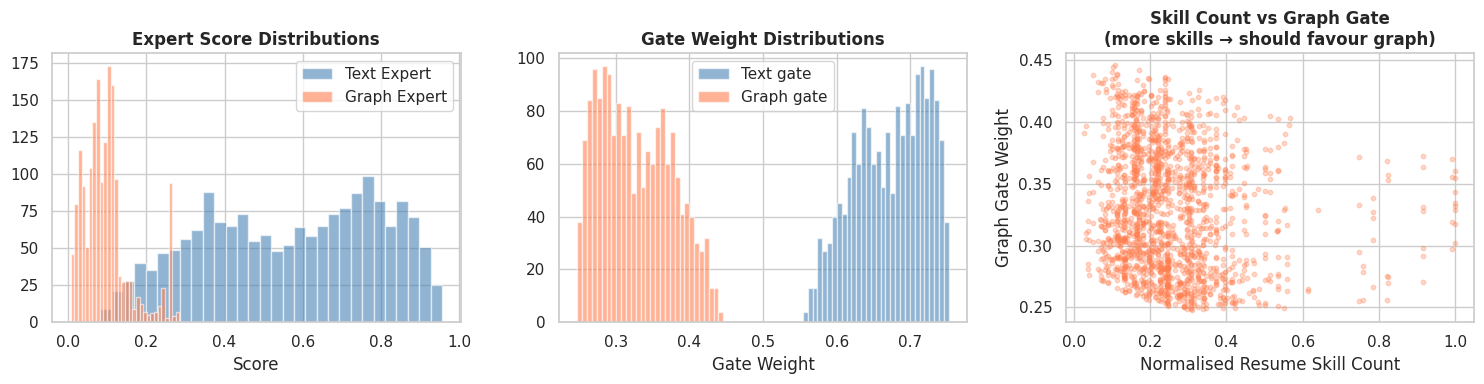

In [15]:
print('Expert Score Statistics')
print(f'  Text  expert — mean: {diag["text_scores"].mean():.3f}  '
      f'std: {diag["text_scores"].std():.3f}')
print(f'  Graph expert — mean: {diag["graph_scores"].mean():.3f}  '
      f'std: {diag["graph_scores"].std():.3f}')
print(f'  (std > 0.05 = healthy, std < 0.02 = collapsed)')

print(f'\nGate Weight Statistics')
print(f'  Mean text  gate: {diag["gate_text"].mean():.3f}')
print(f'  Mean graph gate: {diag["gate_graph"].mean():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Expert score distributions
ax = axes[0]
ax.hist(diag['text_scores'],  bins=30, alpha=0.6,
        color='steelblue', label='Text Expert')
ax.hist(diag['graph_scores'], bins=30, alpha=0.6,
        color='coral',     label='Graph Expert')
ax.set_title('Expert Score Distributions', fontweight='bold')
ax.set_xlabel('Score')
ax.legend()

# Plot 2: Gate weight distributions
ax = axes[1]
ax.hist(diag['gate_text'],  bins=30, alpha=0.6,
        color='steelblue', label='Text gate')
ax.hist(diag['gate_graph'], bins=30, alpha=0.6,
        color='coral',     label='Graph gate')
ax.set_title('Gate Weight Distributions', fontweight='bold')
ax.set_xlabel('Gate Weight')
ax.legend()

# Plot 3: Skill count vs gate weight
# If gate is working correctly, more skills → higher graph gate
ax = axes[2]
ax.scatter(diag['skill_counts'], diag['gate_graph'],
           alpha=0.3, s=10, color='coral')
ax.set_xlabel('Normalised Resume Skill Count')
ax.set_ylabel('Graph Gate Weight')
ax.set_title('Skill Count vs Graph Gate\n'
             '(more skills → should favour graph)', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/moe_v2_diagnostics.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Comparison Table

In [16]:
comparison = pd.DataFrame([
    {'Model': 'TF-IDF (Baseline)',      'MAE': 0.3802, 'Spearman': 0.0908, 'nDCG@10': 0.6328, 'RBO': 0.3927},
    {'Model': 'Pure Semantic',          'MAE': 0.3767, 'Spearman': 0.0899, 'nDCG@10': 0.6453, 'RBO': 0.3946},
    {'Model': 'Late Fusion',            'MAE': 0.3793, 'Spearman': 0.0528, 'nDCG@10': 0.5607, 'RBO': 0.4034},
    {'Model': 'Cross-Attention',        'MAE': 0.3619, 'Spearman': 0.1961, 'nDCG@10': 0.6004, 'RBO': 0.4070},
    {'Model': 'MoE v1',                 'MAE': 0.3737, 'Spearman': 0.1070, 'nDCG@10': 0.6032, 'RBO': 0.4162},
    {'Model': 'MoE v2 (Interpretable)', 'MAE': metrics['MAE'],
                                         'Spearman': metrics['Spearman'],
                                         'nDCG@10':  metrics['nDCG@10'],
                                         'RBO':      metrics['RBO']},
])

print('Full Architecture Comparison:')
print(comparison.to_string(index=False))
comparison.to_csv('/kaggle/working/architecture_comparison.csv', index=False)

Full Architecture Comparison:
                 Model    MAE  Spearman  nDCG@10    RBO
     TF-IDF (Baseline) 0.3802    0.0908   0.6328 0.3927
         Pure Semantic 0.3767    0.0899   0.6453 0.3946
           Late Fusion 0.3793    0.0528   0.5607 0.4034
       Cross-Attention 0.3619    0.1961   0.6004 0.4070
                MoE v1 0.3737    0.1070   0.6032 0.4162
MoE v2 (Interpretable) 0.3414    0.3357   0.7165 0.4291


## Save

In [17]:
torch.save(moe_v2.state_dict(), '/kaggle/working/best_moe_v2.pth')
print('Saved: /kaggle/working/best_moe_v2.pth')
print('Use this as input to the recourse notebook.')

Saved: /kaggle/working/best_moe_v2.pth
Use this as input to the recourse notebook.
